[![UAEM](https://www.uaem.mx/fcaei/images/uaem.png)](https://www.uaem.mx/fcaei/moca.html)
[![Python 3.9](https://img.shields.io/badge/Python-3.9-blue.svg)](https://www.python.org/downloads/release/python-390/)
[![Status](https://img.shields.io/badge/Status-En%20Progreso-yellow.svg)]()

# Tarea: Análisis Estadístico Descriptivo de la Calidad del Aire

**Alumno:** Emiliano Rodriguez Villegas

**Fecha:** 11 de Septiembre de 2025
**Versión:** 1.0

---

## Introducción y Objetivo

Este notebook presenta un análisis estadístico descriptivo del conjunto de datos `AirQualityCleaned.csv`. El objetivo principal es cumplir con los requisitos de la tarea, que consisten en calcular, presentar e interpretar las **medidas de tendencia central** (media, mediana, moda) y las **medidas de dispersión** (varianza, desviación estándar, rango y rango intercuartílico) para las variables cuantitativas del dataset.

El análisis se estructura en fases, desde la preparación de los datos hasta la interpretación final de los resultados.

---

### Índice General del Notebook

1.  [**Fase 1: Preparación del Entorno y Carga de Datos**](#fase-1)
    * [1.1. Importación de Librerías](#1-1)
    * [1.2. Carga del Conjunto de Datos](#1-2)
    * [1.3. Exploración Inicial de los Datos](#1-3)
2.  [**Fase 2: Cálculo de Medidas Estadísticas**](#fase-2)
    * [2.1. Identificación de Variables Cuantitativas](#2-1)
    * [2.2. Cálculo de Medidas de Tendencia Central](#2-2)
    * [2.3. Cálculo de Medidas de Dispersión](#2-3)
    * [2.4. Creación de la Tabla de Resultados](#2-4)
3.  [**Fase 3: Visualización de Datos**](#fase-3)
    * [3.1. Generación de Gráficos de Distribución](#3-1)
4.  [**Fase 4: Interpretación y Conclusiones**](#fase-4)
    * [4.1. Interpretación de Resultados](#4-1)
    * [4.2. Conclusiones Generales](#4-2)

---

## <a id='fase-1'></a>Fase 1: Preparación del Entorno y Carga de Datos

En esta primera fase, importaremos las librerías necesarias y cargaremos el dataset `AirQualityCleaned.csv` usando una variable para la ruta del archivo.

### <a id='1-1'></a>1.1. Importación de Librerías

Aquí se importan las bibliotecas de Python que utilizaremos a lo largo del notebook.


In [89]:

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### <a id='1-2'></a>1.2. Carga del Conjunto de Datos
Se carga el archivo AirQualityCleaned.csv en un DataFrame de Pandas para poder trabajar con él.

In [90]:
import pandas as pd
rutaDatos = '../Data/Air_Quality.csv'
dataFrame = pd.read_csv(rutaDatos)

### <a id='1-3'></a>1.3. Exploración Inicial de los Datos
Realizamos una revisión rápida del DataFrame para entender su estructura, las columnas que contiene y los tipos de datos.

In [91]:
dataFrame.head()


,Date,City,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
0,2024-01-01 00:00:00+00:00,Brasilia,323.0,NaN,23.8,2.8,42.0,12.0,17.1,16.800000
1,2024-01-01 01:00:00+00:00,Brasilia,318.0,NaN,21.9,2.7,40.0,12.5,17.9,16.000000
2,2024-01-01 02:00:00+00:00,Brasilia,309.0,NaN,19.2,2.6,39.0,12.1,17.3,15.599999
3,2024-01-01 03:00:00+00:00,Brasilia,295.0,NaN,16.3,2.4,38.0,11.4,16.2,15.200000
4,2024-01-01 04:00:00+00:00,Brasilia,270.0,NaN,13.0,2.1,40.0,10.2,14.6,16.000000


In [92]:
dataFrame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52704 entries, 0 to 52703
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    52704 non-null  object 
 1   City    52704 non-null  object 
 2   CO      52704 non-null  float64
 3   CO2     9648 non-null   float64
 4   NO2     52704 non-null  float64
 5   SO2     52704 non-null  float64
 6   O3      52704 non-null  float64
 7   PM2.5   52704 non-null  float64
 8   PM10    52704 non-null  float64
 9   AQI     52704 non-null  float64
dtypes: float64(8), object(2)
memory usage: 4.0+ MB


---

## <a id='fase-2'></a>Fase 2: Cálculo de Medidas Estadísticas

Tarea: calcular las medidas estadísticas solicitadas para todas las variables cuantitativas identificadas.

### <a id='2-1'></a>2.1. Identificación de Variables Cuantitativas

Primero, identificamos cuáles de las columnas del `dataFrame` son numéricas (cuantitativas), ya que sobre estas realizaremos los cálculos.



In [93]:

variablesCuantitativas = dataFrame.select_dtypes(include=np.number)

print("Variables cuantitativas:")
print(variablesCuantitativas.columns.tolist())

Variables cuantitativas:
['CO', 'CO2', 'NO2', 'SO2', 'O3', 'PM2.5', 'PM10', 'AQI']


### <a id='2-2'></a>2.2. Medidas de Tendencia Central
Calculamos la media, mediana y moda para cada variable cuantitativa.

In [94]:
media = variablesCuantitativas.mean()
mediana = variablesCuantitativas.median()
moda = variablesCuantitativas.mode().iloc[0]


print("--- Medidas de Tendencia Central ---")
print("\nMedia:\n", media)
print("\nMediana:\n", mediana)
print("\nModa:\n", moda)

--- Medidas de Tendencia Central ---

Media:
 CO       258.258121
CO2      462.348259
NO2       24.102998
SO2       12.569869
O3        60.025729
PM2.5     17.689931
PM10      35.643143
AQI       41.349339
dtype: float64

Mediana:
 CO       213.000000
CO2      453.000000
NO2       18.900000
SO2        5.700000
O3        54.000000
PM2.5     12.500000
PM10      18.900000
AQI       31.270835
dtype: float64

Moda:
 CO       175.0
CO2      445.0
NO2       10.3
SO2        1.4
O3        54.0
PM2.5      8.4
PM10      12.3
AQI       21.6
Name: 0, dtype: float64


### <a id='2-3'></a>2.3. Medidas de Dispersión

Calculamos la varianza, desviación estándar, rango y rango intercuartílico (IQR).

In [95]:
# Cálculo de la varianza
varianza = variablesCuantitativas.var()

# Cálculo de la desviación estándar
desviacionEstandar = variablesCuantitativas.std()




print("--- Medidas de Dispersión ---")
print("\nVarianza:\n", varianza)
print("\nDesviación Estándar:\n", desviacionEstandar)



--- Medidas de Dispersión ---

Varianza:
 CO       25468.953087
CO2       1140.345999
NO2        374.942943
SO2        298.136276
O3        1460.565719
PM2.5      245.551259
PM10      2346.896150
AQI        708.951820
dtype: float64

Desviación Estándar:
 CO       159.589953
CO2       33.769009
NO2       19.363443
SO2       17.266623
O3        38.217348
PM2.5     15.670075
PM10      48.444774
AQI       26.626149
dtype: float64


In [96]:

# Cálculo del rango (Máximo - Mínimo)
rango = variablesCuantitativas.max() - variablesCuantitativas.min()

# Cálculo del Rango Intercuartílico (IQR)
q1 = variablesCuantitativas.quantile(0.25)
q3 = variablesCuantitativas.quantile(0.75)
iqr = q3 - q1

print("\nRango Intercuartílico (IQR):\n", iqr)
print("\nRango:\n", rango)


Rango Intercuartílico (IQR):
 CO       147.000000
CO2       22.000000
NO2       23.700000
SO2       14.500000
O3        43.000000
PM2.5     16.100000
PM10      27.300000
AQI       34.902089
dtype: float64

Rango:
 CO       1993.00000
CO2       450.00000
NO2       165.90000
SO2       239.70000
O3        349.00000
PM2.5     129.40000
PM10      543.80000
AQI       192.18333
dtype: float64


### <a id='2-4'></a>2.4. Tabla de Resultados

In [97]:
# Crear un nuevo DataFrame para almacenar los resultados
tablaResultados = pd.DataFrame({
    'Media': media,
    'Mediana': mediana,
    'Moda': moda,
    'Varianza': varianza,
    'DesviacionEstandar': desviacionEstandar,
    'Rango': rango,
    'IQR': iqr
})


tablaResultados

,Media,Mediana,Moda,Varianza,DesviacionEstandar,Rango,IQR
CO,258.258121,213.000000,175.0,25468.953087,159.589953,1993.00000,147.000000
CO2,462.348259,453.000000,445.0,1140.345999,33.769009,450.00000,22.000000
NO2,24.102998,18.900000,10.3,374.942943,19.363443,165.90000,23.700000
SO2,12.569869,5.700000,1.4,298.136276,17.266623,239.70000,14.500000
O3,60.025729,54.000000,54.0,1460.565719,38.217348,349.00000,43.000000
PM2.5,17.689931,12.500000,8.4,245.551259,15.670075,129.40000,16.100000
PM10,35.643143,18.900000,12.3,2346.896150,48.444774,543.80000,27.300000
AQI,41.349339,31.270835,21.6,708.951820,26.626149,192.18333,34.902089


## <a id='fase-3'></a>Fase 3: Visualización de Datos

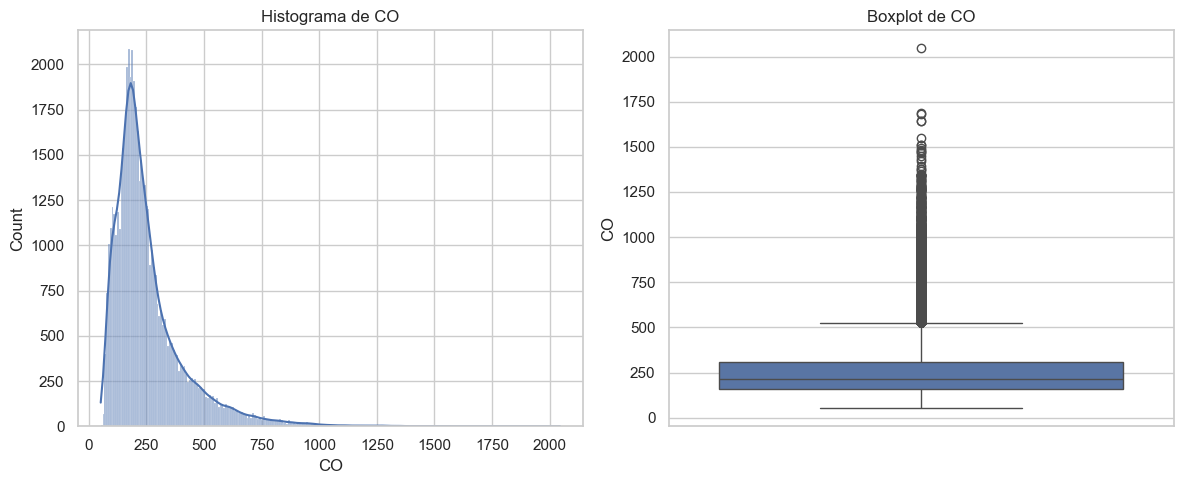

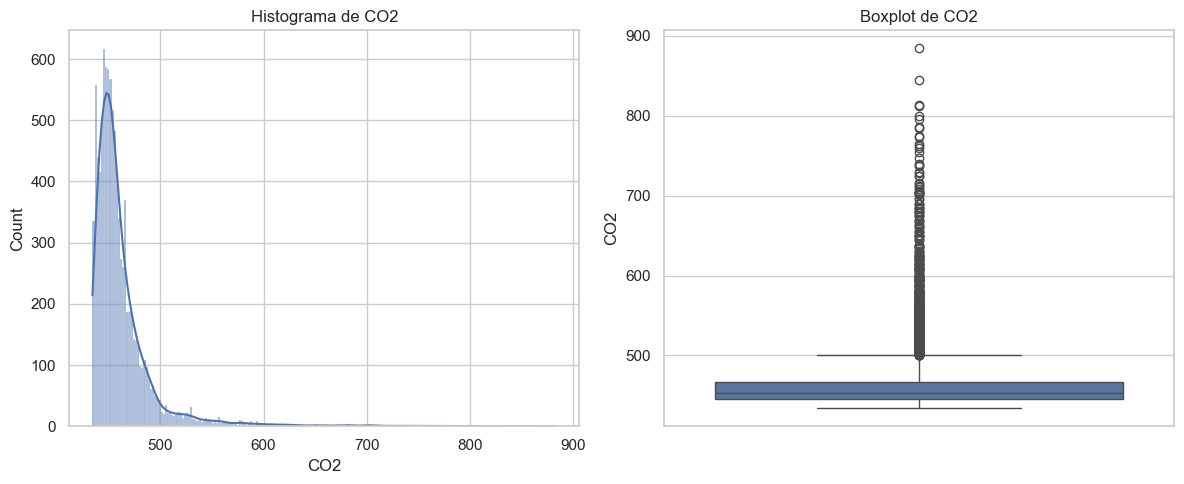

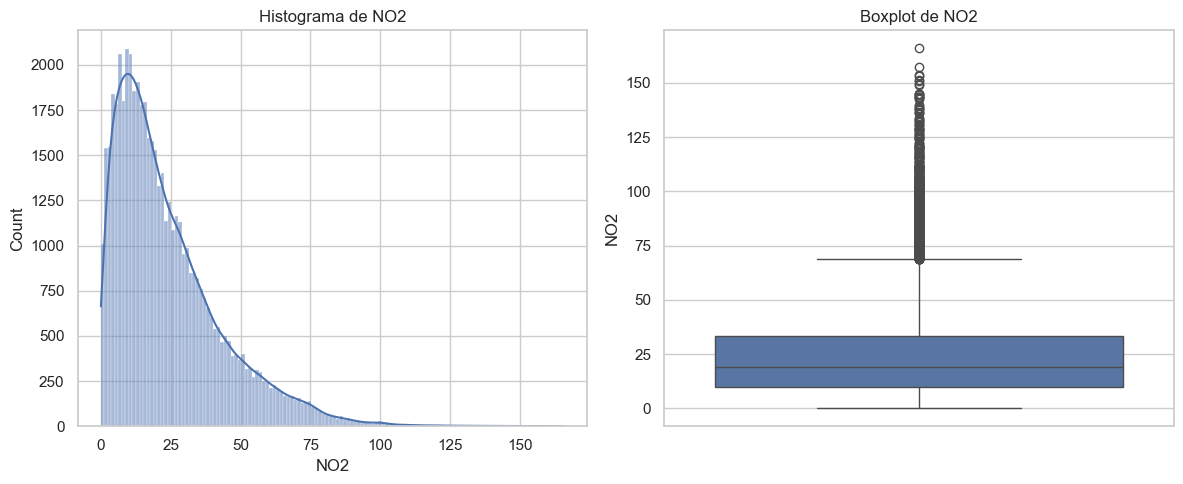

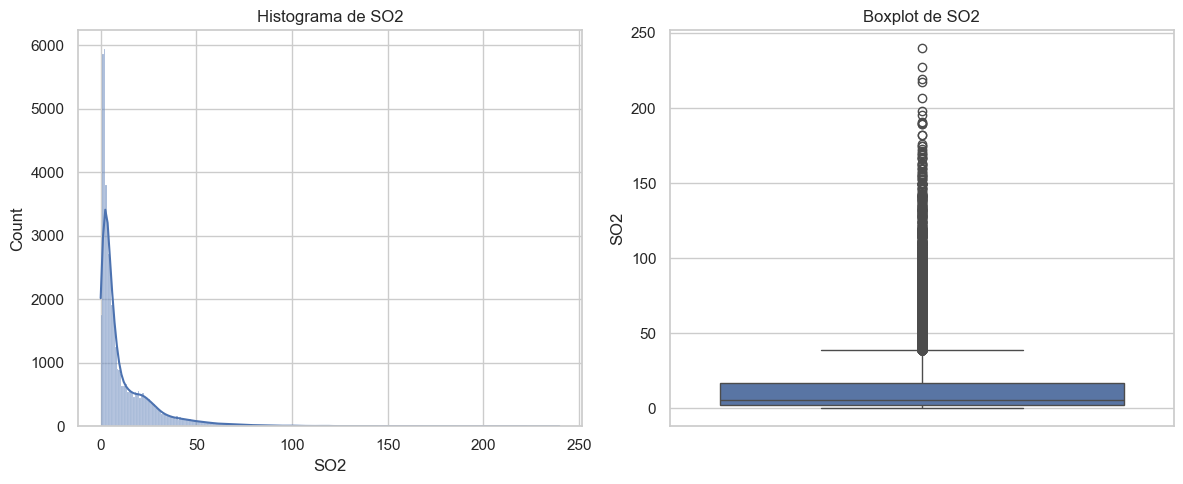

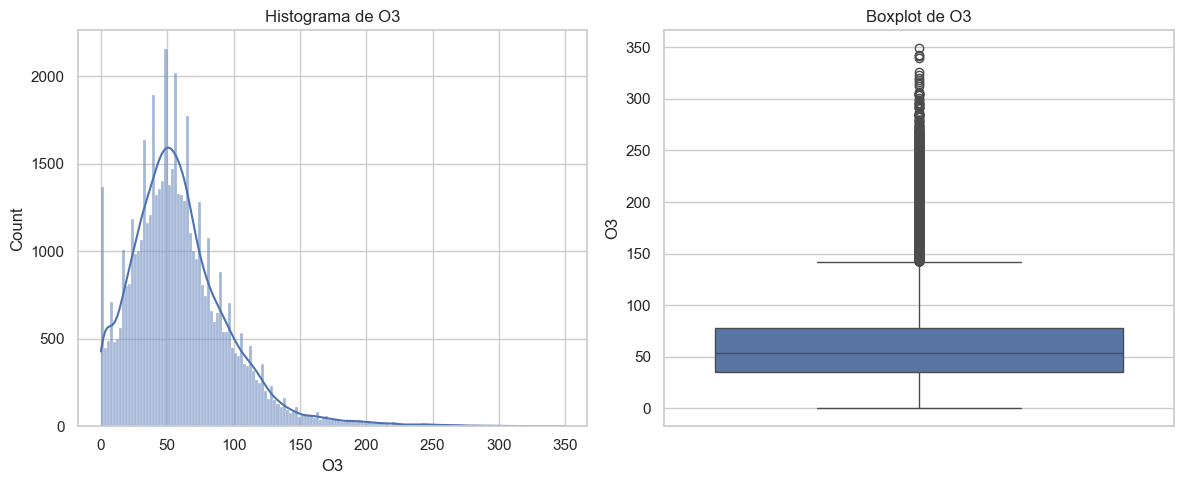

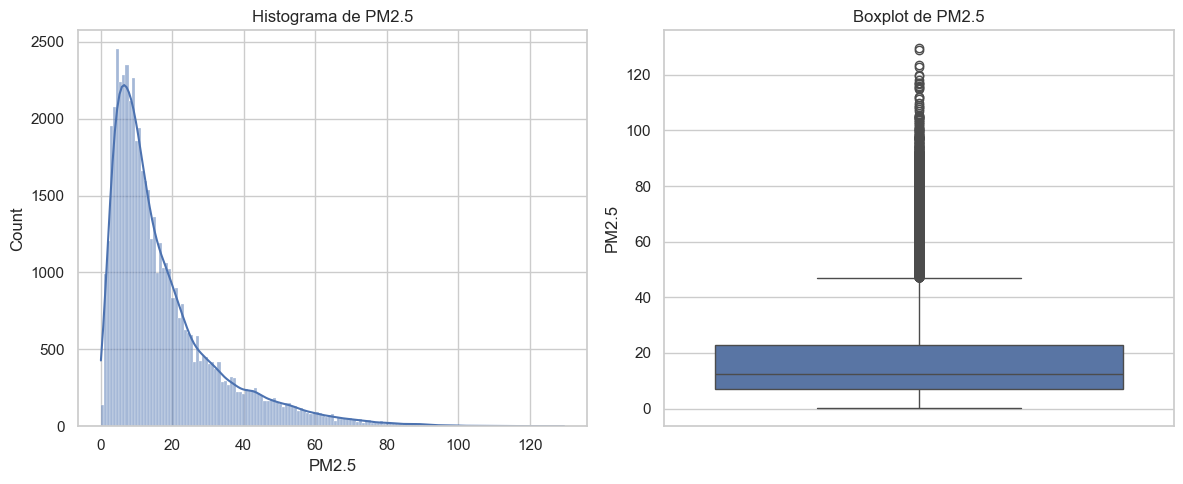

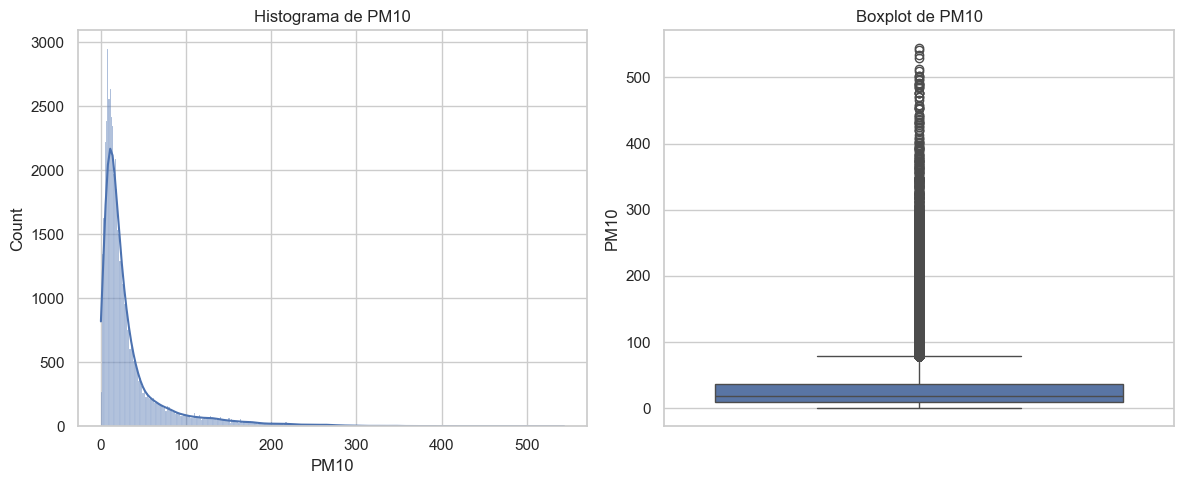

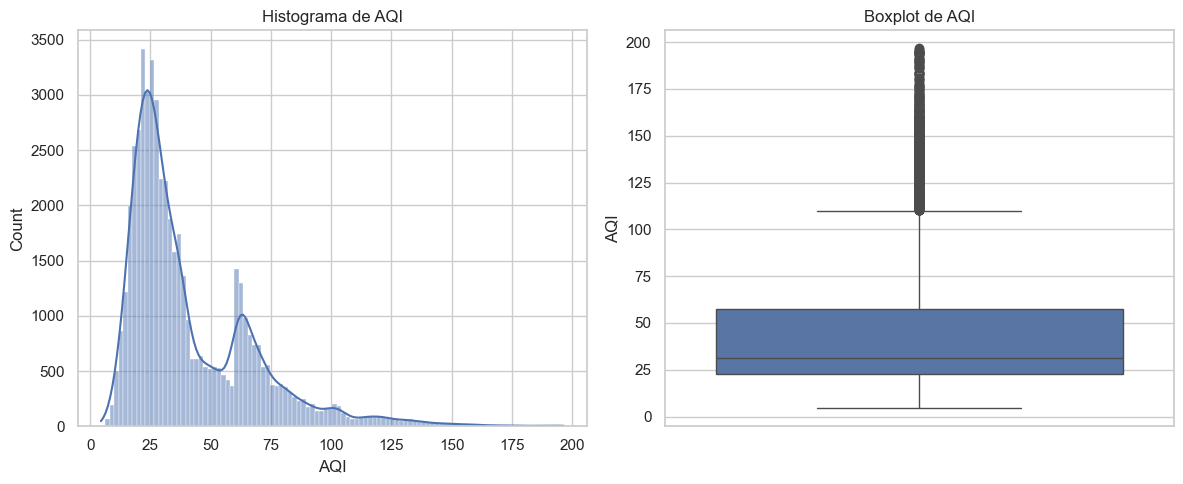

In [98]:
for col in variablesCuantitativas.columns:

    plt.figure(figsize=(12, 5))
    

    plt.subplot(1, 2, 1)
    sns.histplot(data=variablesCuantitativas, x=col, kde=True)
    plt.title(f'Histograma de {col}')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(data=variablesCuantitativas, y=col)
    plt.title(f'Boxplot de {col}')
    
    plt.tight_layout()
    plt.show()

---

## <a id='fase-4'></a>Fase 4: Interpretación y Conclusiones

Interpretacion de los datos

### <a id='4-1'></a>4.1. Interpretación de Resultados


**Análisis de Tendencia Central:**

* **¿Las medidas de tendencia central (media, mediana, moda) son similares o diferentes para cada variable?**
    * **Respuesta:** Para la mayoría de las variables contaminantes (como CO, NO2, SO2, O3, PM2.5 y PM10), las medidas de tendencia central son **notablemente diferentes**. Se observa un patrón consistente donde la **Media > Mediana > Moda**. Por ejemplo, para el CO, la media es 258.2, la mediana es 213.0 y la moda es 175.0.

* **¿Qué nos dice esto sobre la distribución de los datos?**
    * **Respuesta:** Esta diferencia indica que las distribuciones de los datos tienen un **sesgo positivo o a la derecha**. Esto se confirma visualmente en el histograma del CO, que muestra una gran concentración de datos en valores bajos y una "cola" larga hacia los valores altos. Los valores extremadamente altos (atípicos) están "jalando" la media hacia arriba, mientras que la mediana y la moda se mantienen en la zona donde se agrupan la mayoría de los datos.

**Análisis de Dispersión:**

* **¿Qué indican las medidas de dispersión (desviación estándar, rango, IQR) sobre la variabilidad de los datos en cada variable?**
    * **Respuesta:** Las medidas de dispersión revelan una alta variabilidad en la mayoría de los contaminantes.
        * El **Rango** es muy amplio para casi todas las variables (ej. 1993.0 para el CO), lo que indica una enorme diferencia entre las mediciones mínimas y máximas, probablemente debido a valores atípicos.
        * La **Desviación Estándar** es también considerablemente alta en comparación con la media, confirmando que los datos están muy dispersos.
        * El **Rango Intercuartílico (IQR)** es relativamente pequeño en comparación con el rango total. Como se ve en el boxplot del CO, esto significa que el 50% central de los datos está bastante agrupado, pero existen muchos valores extremos fuera de este rango.

* **¿Qué variables presentan mayor y menor variabilidad?**
    * **Respuesta:** La variable **SO2** parece ser la de mayor variabilidad relativa (su desviación estándar de 17.2 es mayor que su media de 12.5). En contraste, la variable **CO2** es la más estable, con una desviación estándar (33.7) que es muy pequeña en proporción a su media (462.3).

### <a id='4-2'></a>4.2. Conclusiones Generales

* **Respuesta:** El análisis estadístico descriptivo revela que los datos de calidad del aire no se distribuyen de manera normal. La mayoría de los contaminantes muestran un fuerte **sesgo a la derecha**, lo que sugiere que los niveles de polución son generalmente bajos, pero con episodios esporádicos de concentraciones muy altas. Estos picos extremos elevan el promedio (media), haciendo que la **mediana sea un indicador más robusto** del nivel de contaminación "típico". La alta dispersión en la mayoría de las variables subraya la volatilidad y la naturaleza dinámica de la calidad del aire.